In [1]:
import numpy as np 
import pandas as pd 
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df_null = df.columns[df.isnull().any()]
df[df_null].isnull().sum() *100/df.shape[0]

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [5]:
df_dropped = df.drop(columns = ["Alley","MasVnrType","PoolQC","Fence","MiscFeature"])
df_dropped_null = df_dropped.columns[df_dropped.isnull().any()]
df_dropped[df_dropped_null].isnull().sum() *100/df_dropped.shape[0]

LotFrontage     17.739726
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
dtype: float64

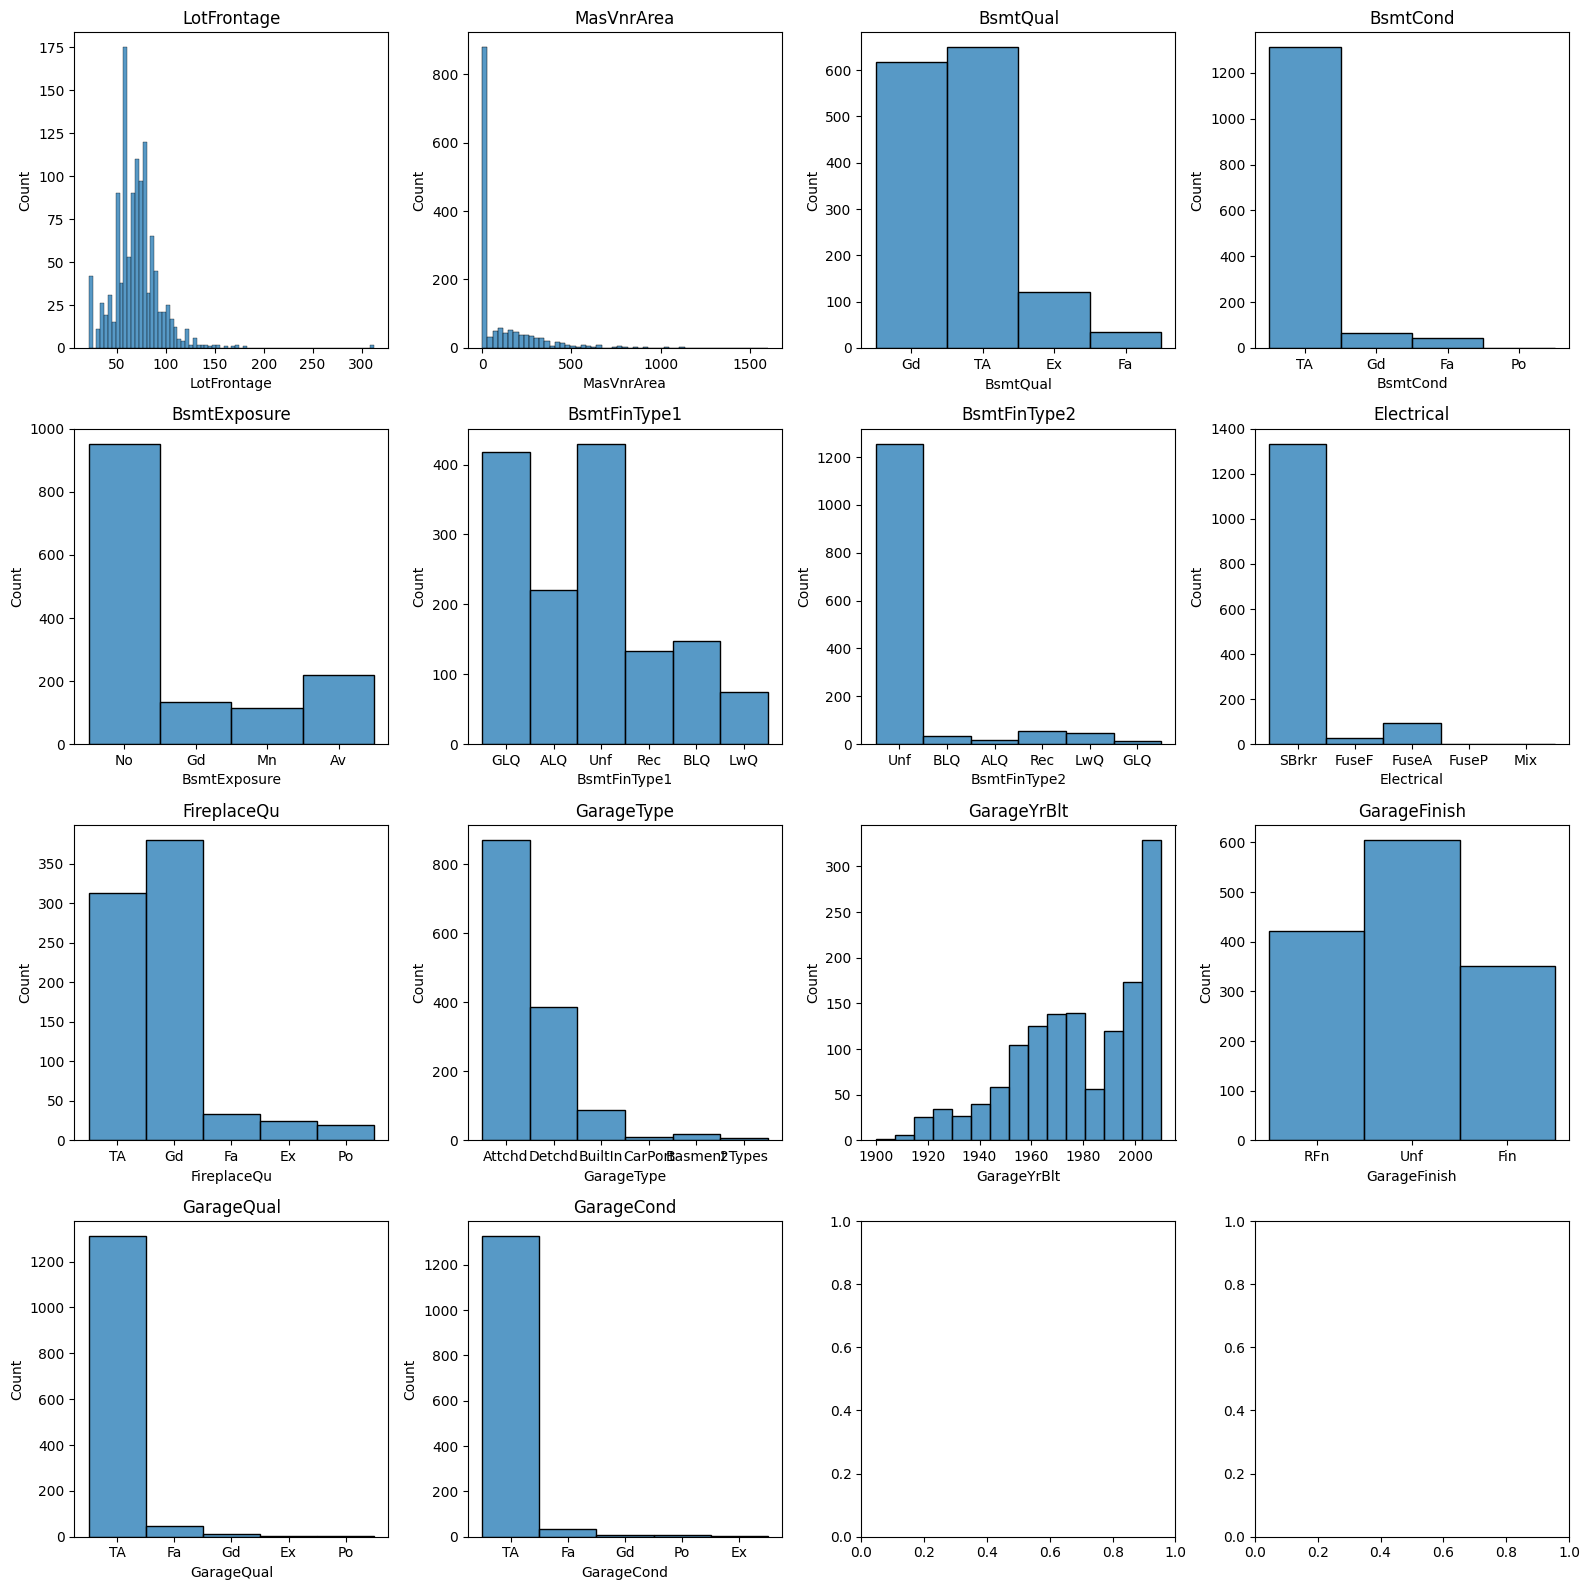

In [6]:
col = 4
row = (len(df_dropped_null)//4) +1

fig,axes = plt.subplots(nrows = row, ncols = col, figsize=(16,4*row))
axes = axes.flatten()

for i, x in enumerate(df_dropped_null):
    sns.histplot(ax=axes[i],x=df[x])
    axes[i].set_title(x)

plt.tight_layout()
plt.show()

In [7]:
mean = ["LotFrontage"]
median = ["MasVnrArea","GarageYrBlt"]
mode = df_dropped.select_dtypes(include="object")

for x in mean:
    df_dropped[x] = df[x].fillna((df[x]).mean())

for x in median:
    df_dropped[x] = df[x].fillna((df[x]).median())

for x in mode:
    df_dropped[x] = df[x].fillna((df[x]).mode()[0])

In [8]:
df_dropped[df_dropped_null].isnull().sum() *100/df_dropped.shape[0]
df_handled = df_dropped.copy()

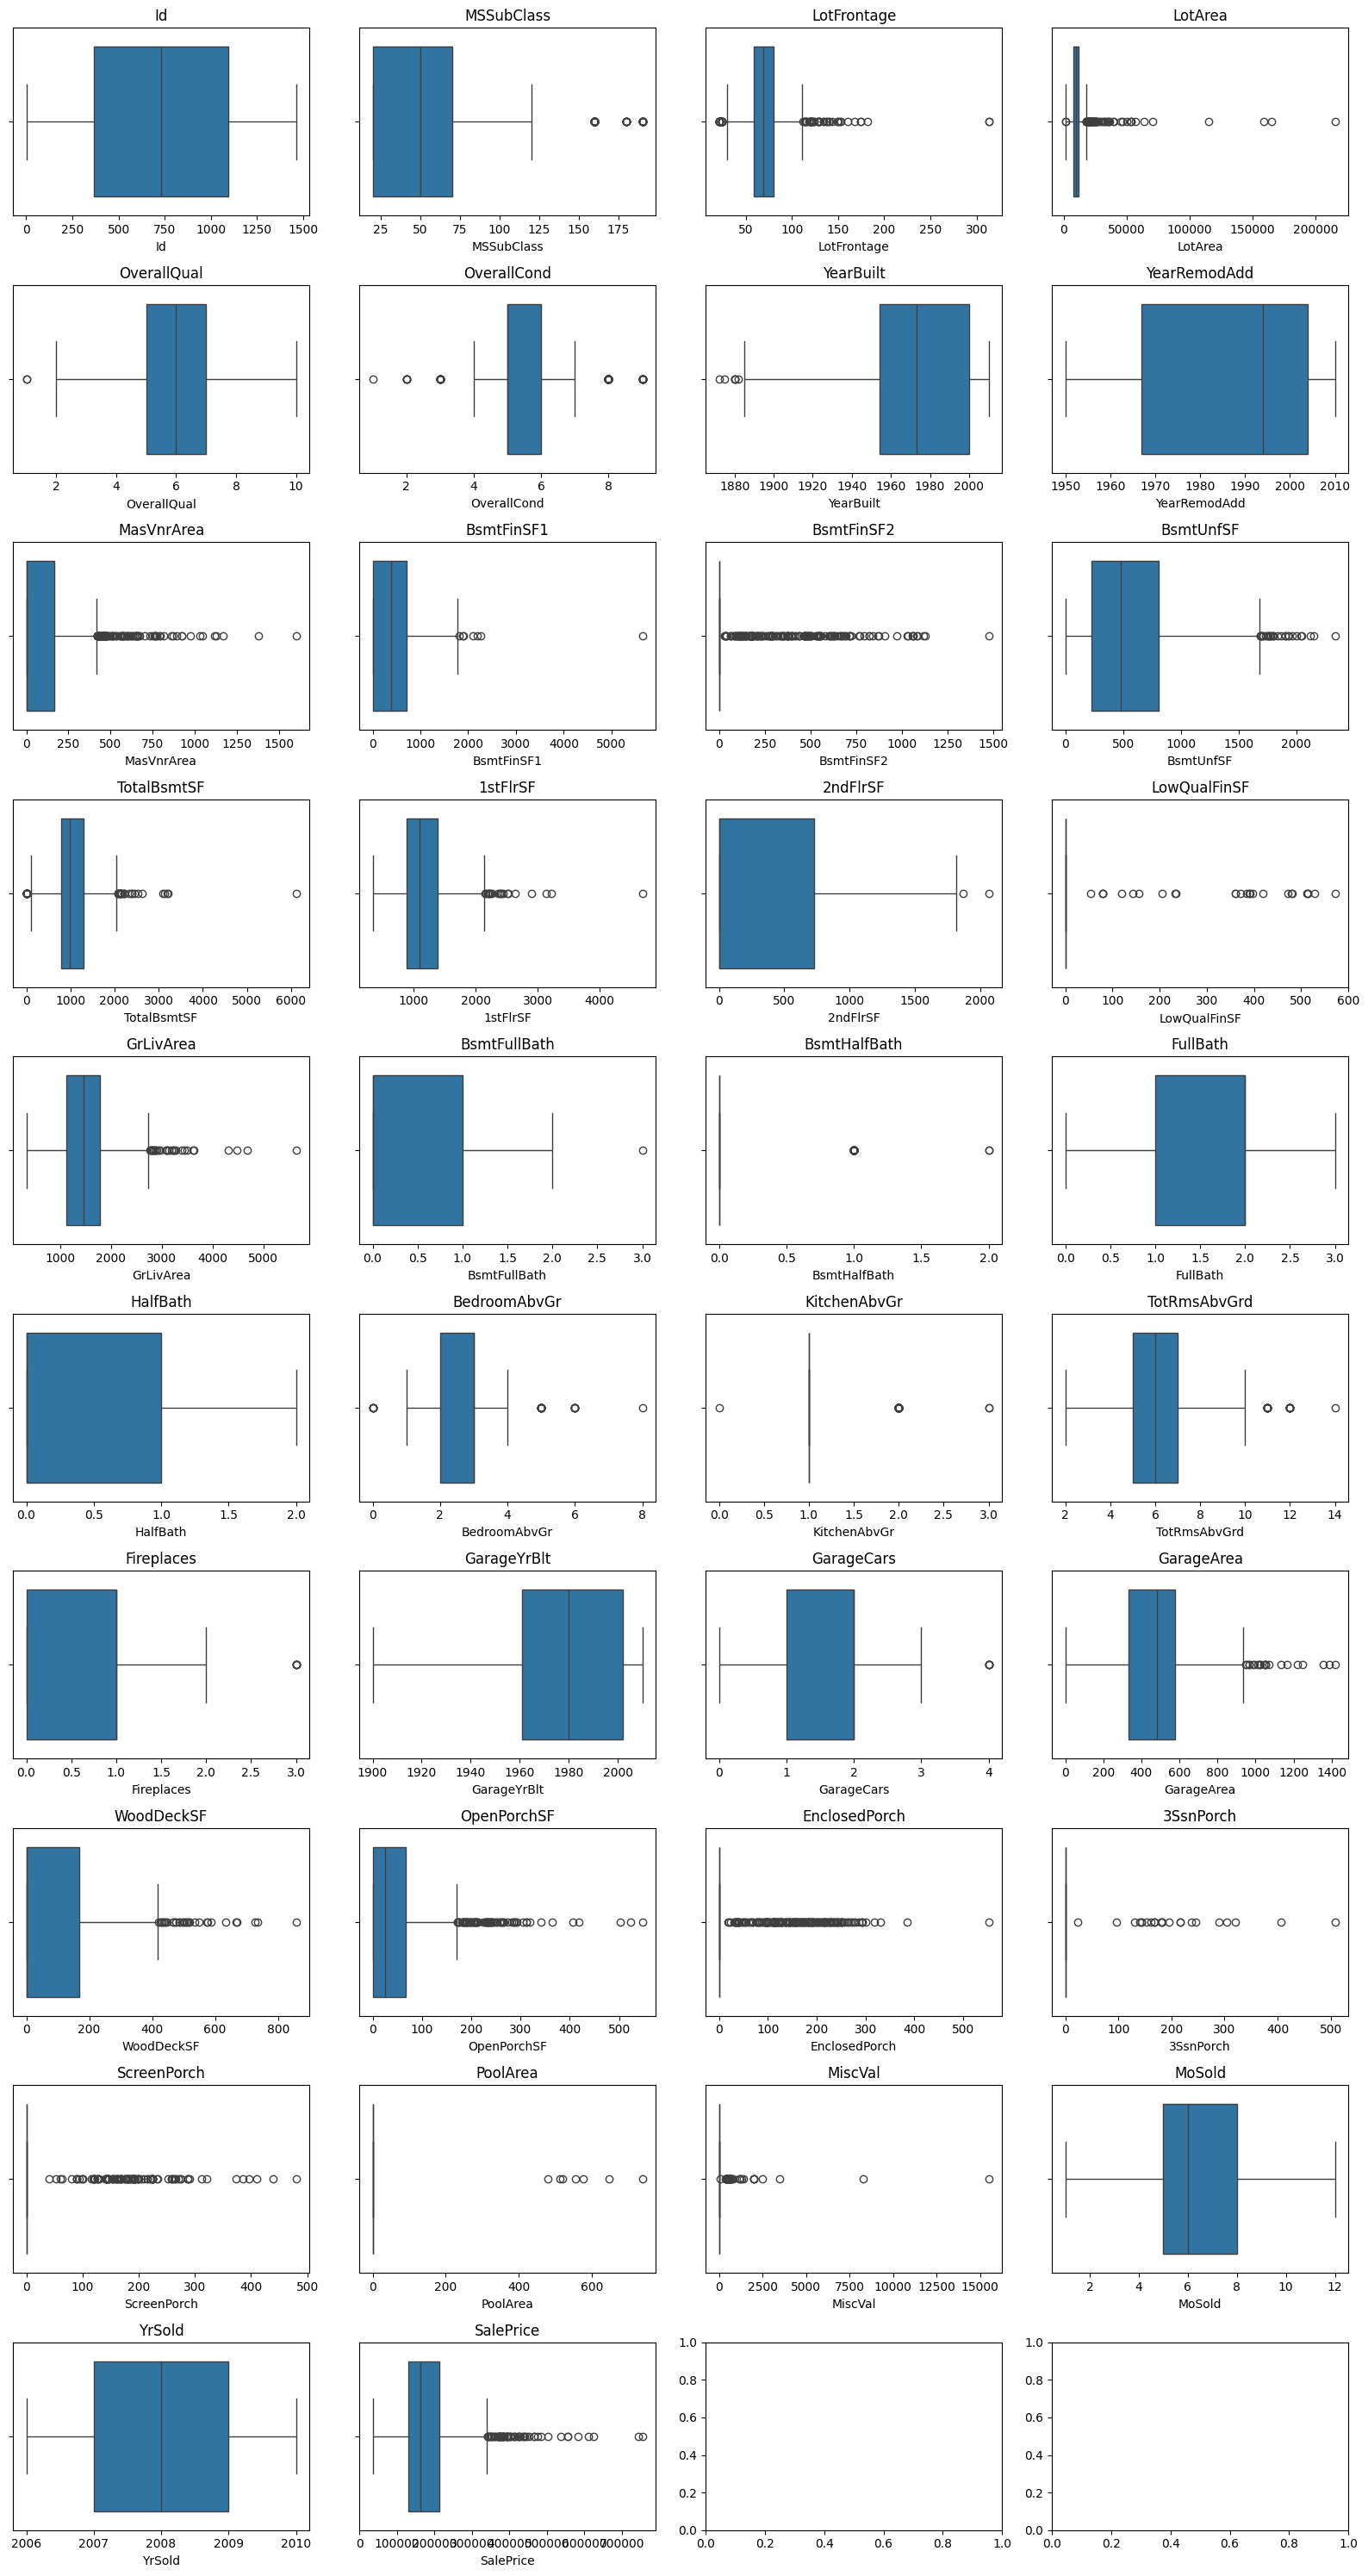

In [9]:
df_handled_numeric = df_handled.select_dtypes(include = ["int64","float64"]).columns
col = 4
row = (len(df_handled_numeric)//col)+1

fig,axes = plt.subplots(nrows = row, ncols = 4,figsize=(16,3*row))
axes = axes.flatten()

for i,x in enumerate(df_handled_numeric):
    sns.boxplot(ax = axes[i], x = df[x])
    axes[i].set_title(f"{x}")
    
plt.tight_layout()
plt.show()
    

In [10]:
df_handled_outlier = df_handled.select_dtypes(include = ["int64","float64"])
Q1 = df_handled_outlier.quantile(0.25)
Q3 = df_handled_outlier.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df_handled_outlier < lower) | (df_handled_outlier > upper)).sum()*100/df_handled.shape[0]
outliers

Id                0.000000
MSSubClass        7.054795
LotFrontage       7.260274
LotArea           4.726027
OverallQual       0.136986
OverallCond       8.561644
YearBuilt         0.479452
YearRemodAdd      0.000000
MasVnrArea        6.712329
BsmtFinSF1        0.479452
BsmtFinSF2       11.438356
BsmtUnfSF         1.986301
TotalBsmtSF       4.178082
1stFlrSF          1.369863
2ndFlrSF          0.136986
LowQualFinSF      1.780822
GrLivArea         2.123288
BsmtFullBath      0.068493
BsmtHalfBath      5.616438
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      2.397260
KitchenAbvGr      4.657534
TotRmsAbvGrd      2.054795
Fireplaces        0.342466
GarageYrBlt       0.068493
GarageCars        0.342466
GarageArea        1.438356
WoodDeckSF        2.191781
OpenPorchSF       5.273973
EnclosedPorch    14.246575
3SsnPorch         1.643836
ScreenPorch       7.945205
PoolArea          0.479452
MiscVal           3.561644
MoSold            0.000000
YrSold            0.000000
S

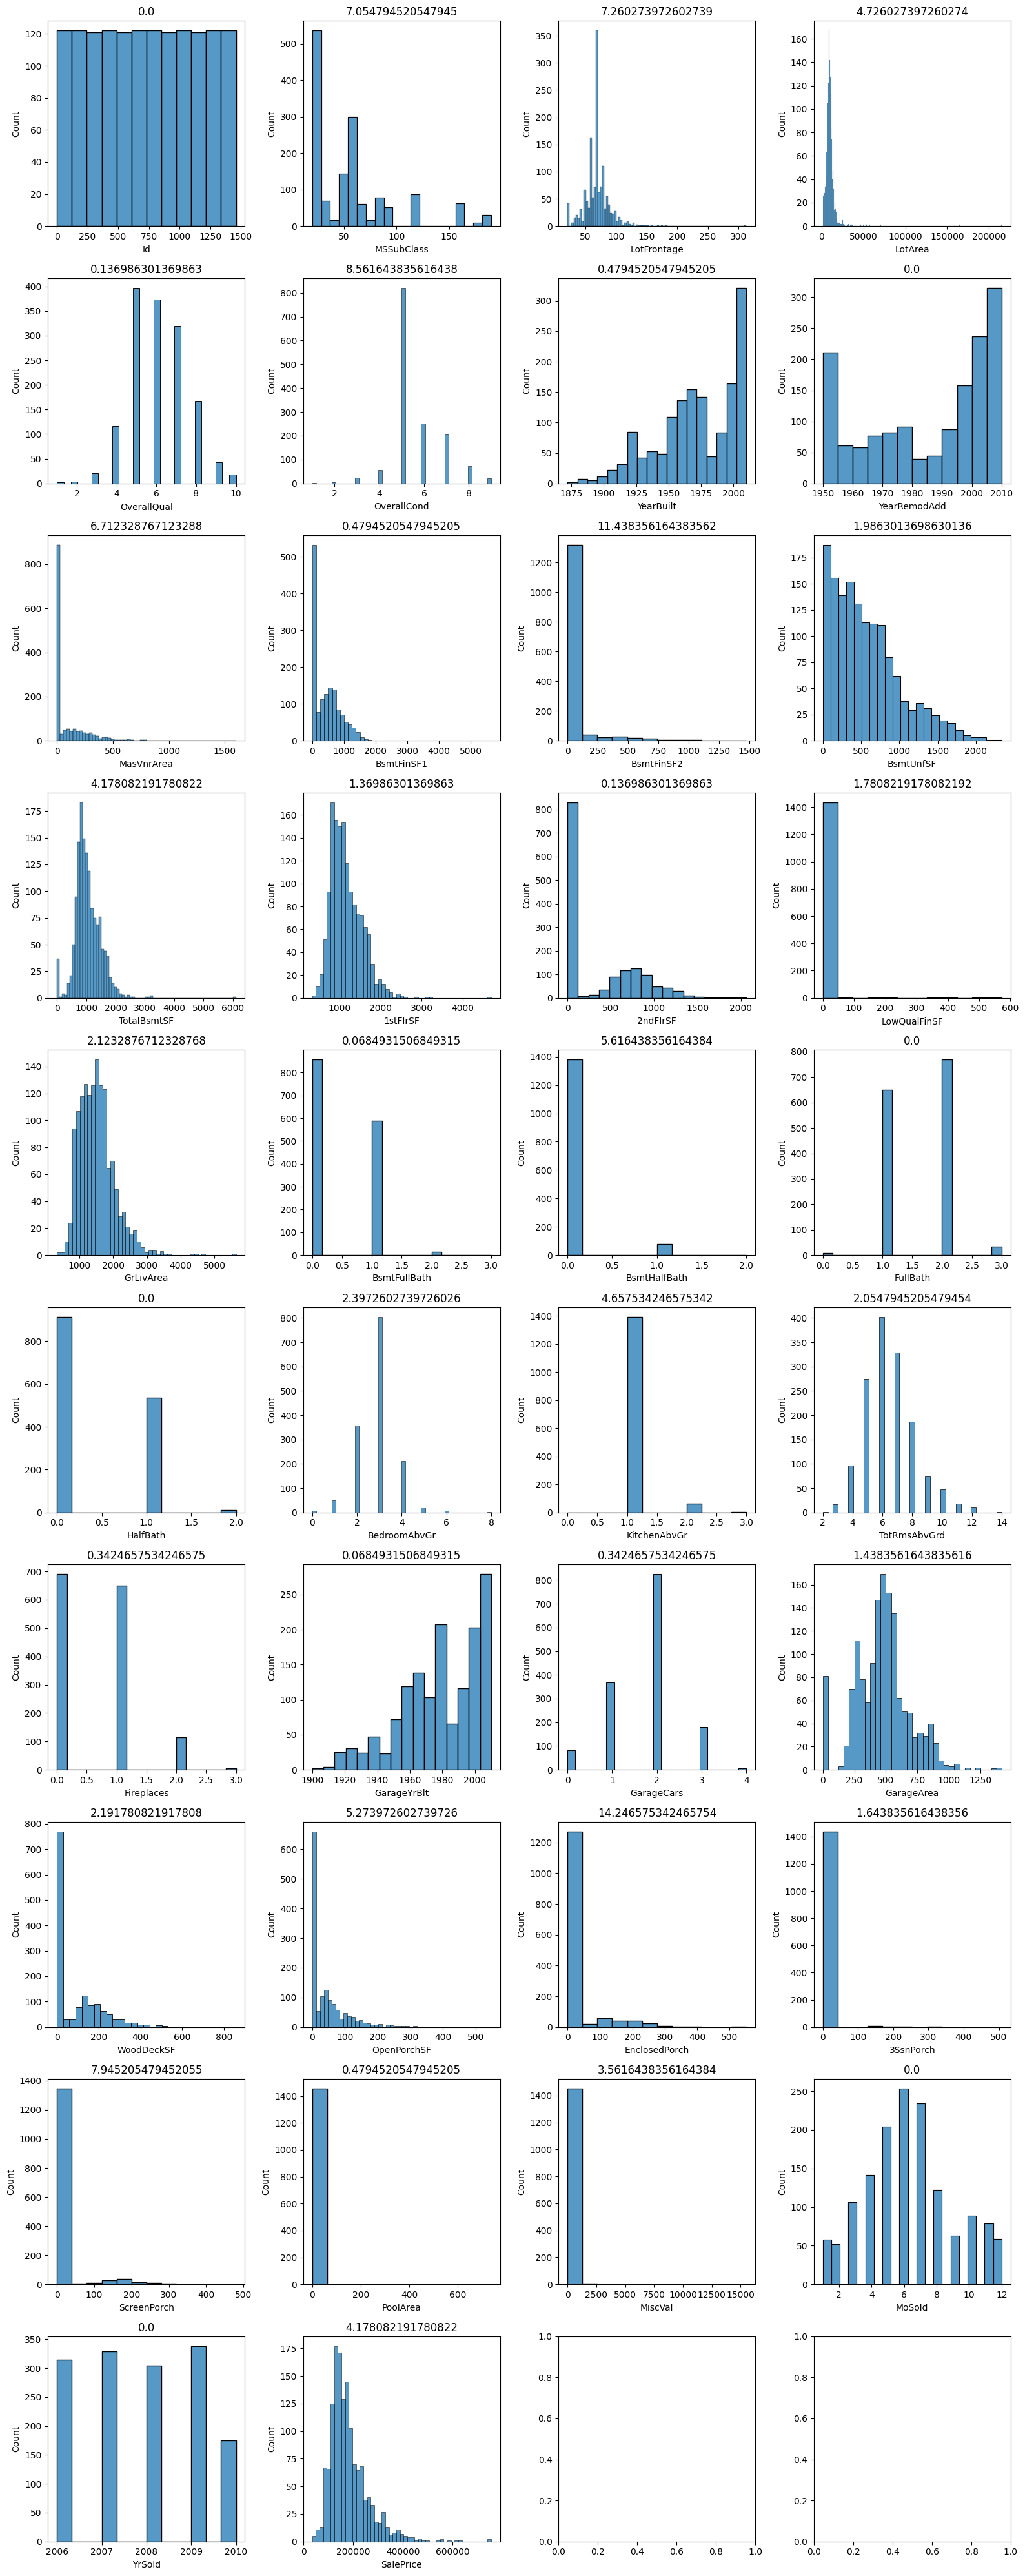

In [11]:
df_handled_outlier_col = df_handled_outlier.columns
col = 4
row = len(df_handled_outlier_col)//4+1

fig,axes = plt.subplots(nrows = row, ncols = col, figsize = (16,4*row))
axes = axes.flatten()

for i, x in enumerate(df_handled_outlier_col):
    sns.histplot(x= df_handled[x],ax=axes[i])
    
    axes[i].set_title(outliers[x])

plt.tight_layout()
plt.show()

In [12]:
df_handled_outlier.nunique()

Id               1460
MSSubClass         15
LotFrontage       111
LotArea          1073
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
MasVnrArea        327
BsmtFinSF1        637
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
1stFlrSF          753
2ndFlrSF          417
LowQualFinSF       24
GrLivArea         861
BsmtFullBath        4
BsmtHalfBath        3
FullBath            4
HalfBath            3
BedroomAbvGr        8
KitchenAbvGr        4
TotRmsAbvGrd       12
Fireplaces          4
GarageYrBlt        97
GarageCars          5
GarageArea        441
WoodDeckSF        274
OpenPorchSF       202
EnclosedPorch     120
3SsnPorch          20
ScreenPorch        76
PoolArea            8
MiscVal            21
MoSold             12
YrSold              5
SalePrice         663
dtype: int64

In [13]:
skewed_data = []
non_skewed_data = []
for x in df_handled_outlier_col:
    if abs(stats.skew(df_handled_outlier[x]))<0.5:
        non_skewed_data.append(x)
    else:
        skewed_data.append(x)
print(len(skewed_data))
print(len(non_skewed_data))


30
8


In [14]:
for x in skewed_data:
    skewed_col = df_handled[x]
    Q3 = skewed_col.quantile(0.75)
    Q1 = skewed_col.quantile(0.25)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = skewed_col.median()
    skewed_col[(skewed_col<lower)|(skewed_col>upper)] = median

for x in non_skewed_data:
    non_skewed_col = df_handled[x]
    Q3 = non_skewed_col.quantile(0.75)
    Q1 = non_skewed_col.quantile(0.25)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mean = non_skewed_col.mean()
    non_skewed_col[(non_skewed_col<lower)|(non_skewed_col>upper)]=mean

C:\Users\Lazzain\AppData\Local\Temp\ipykernel_18812\2479415411.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  skewed_col[(skewed_col<lower)|(skewed_col>upper)] = median
C:\Users\Lazzain\AppData\Local\Temp\ipykernel_18812\2479415411.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  skewed_col[(skewed_col<lower)|(skewed_col>upper)] = median
C:\Users\Lazzain\AppData\Local\Temp\ipykernel_18812\2479415411.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning

In [15]:
df_handled_outlier = df_handled.select_dtypes(include = ["int64","float64"])
Q1 = df_handled_outlier.quantile(0.25)
Q3 = df_handled_outlier.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df_handled_outlier < lower) | (df_handled_outlier > upper)).sum()*100/df_handled.shape[0]
print(outliers)


Id               0.000000
MSSubClass       0.000000
LotFrontage      6.095890
LotArea          3.698630
OverallQual      0.000000
OverallCond      0.000000
YearBuilt        0.000000
YearRemodAdd     0.000000
MasVnrArea       8.150685
BsmtFinSF1       0.068493
BsmtFinSF2       0.000000
BsmtUnfSF        0.890411
TotalBsmtSF      0.958904
1stFlrSF         0.410959
2ndFlrSF         0.000000
LowQualFinSF     0.000000
GrLivArea        0.684932
BsmtFullBath     0.000000
BsmtHalfBath     0.000000
FullBath         0.000000
HalfBath         0.000000
BedroomAbvGr     0.000000
KitchenAbvGr     0.000000
TotRmsAbvGrd     0.000000
Fireplaces       0.000000
GarageYrBlt      0.000000
GarageCars       0.000000
GarageArea       0.000000
WoodDeckSF       0.547945
OpenPorchSF      3.287671
EnclosedPorch    0.000000
3SsnPorch        0.000000
ScreenPorch      0.000000
PoolArea         0.000000
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
SalePrice        3.287671
dtype: float

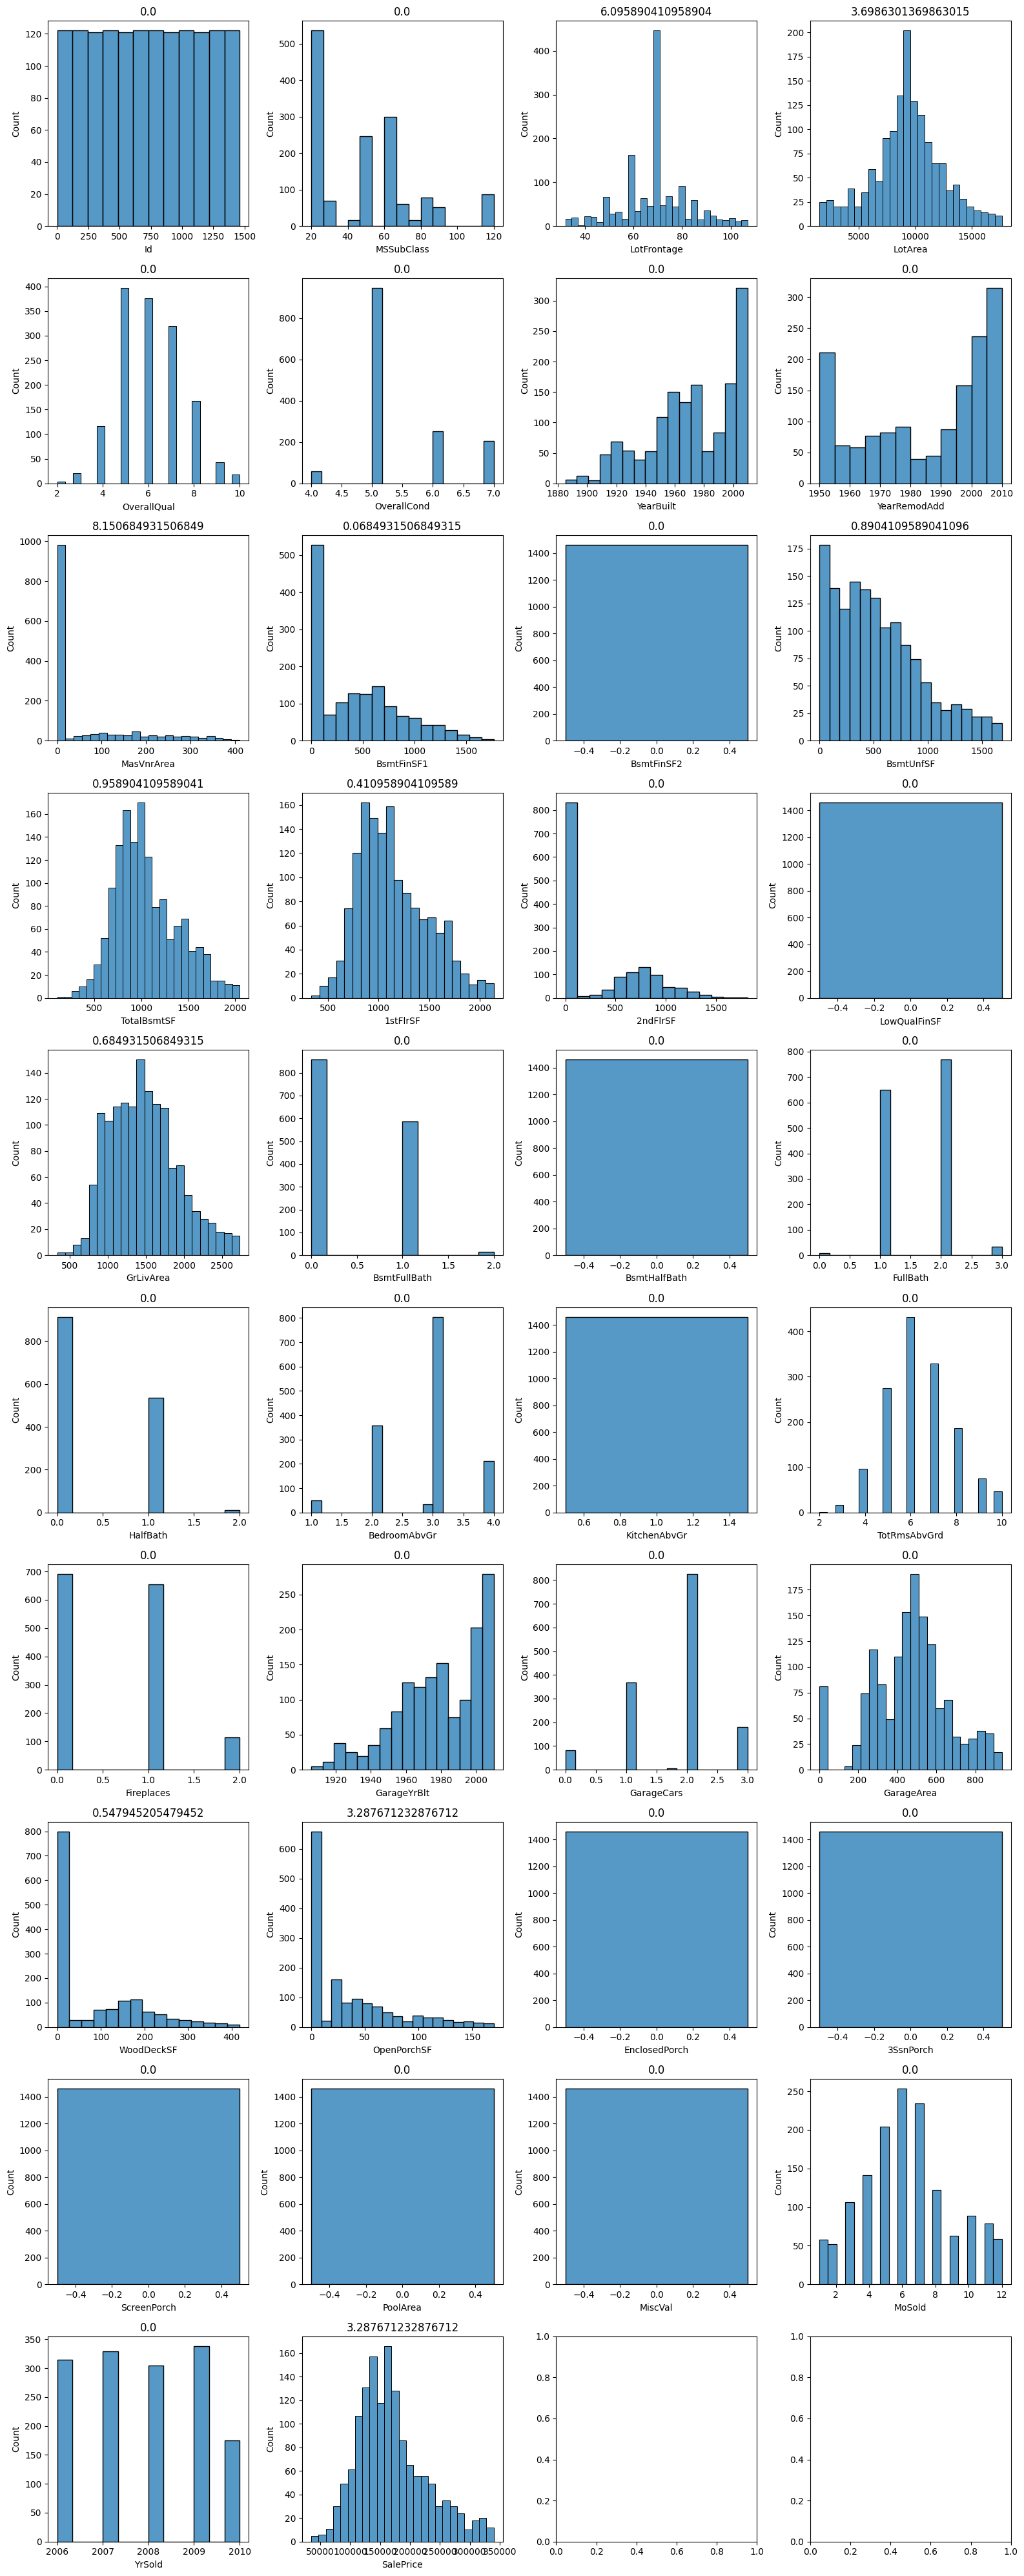

In [16]:
df_handled_outlier_col = df_handled_outlier.columns
col = 4
row = len(df_handled_outlier_col)//4+1

fig,axes = plt.subplots(nrows = row, ncols = col, figsize = (16,4*row))
axes = axes.flatten()

for i, x in enumerate(df_handled_outlier_col):
    sns.histplot(x= df_handled_outlier[x],ax=axes[i])
    
    axes[i].set_title(outliers[x])

plt.tight_layout()
plt.show()

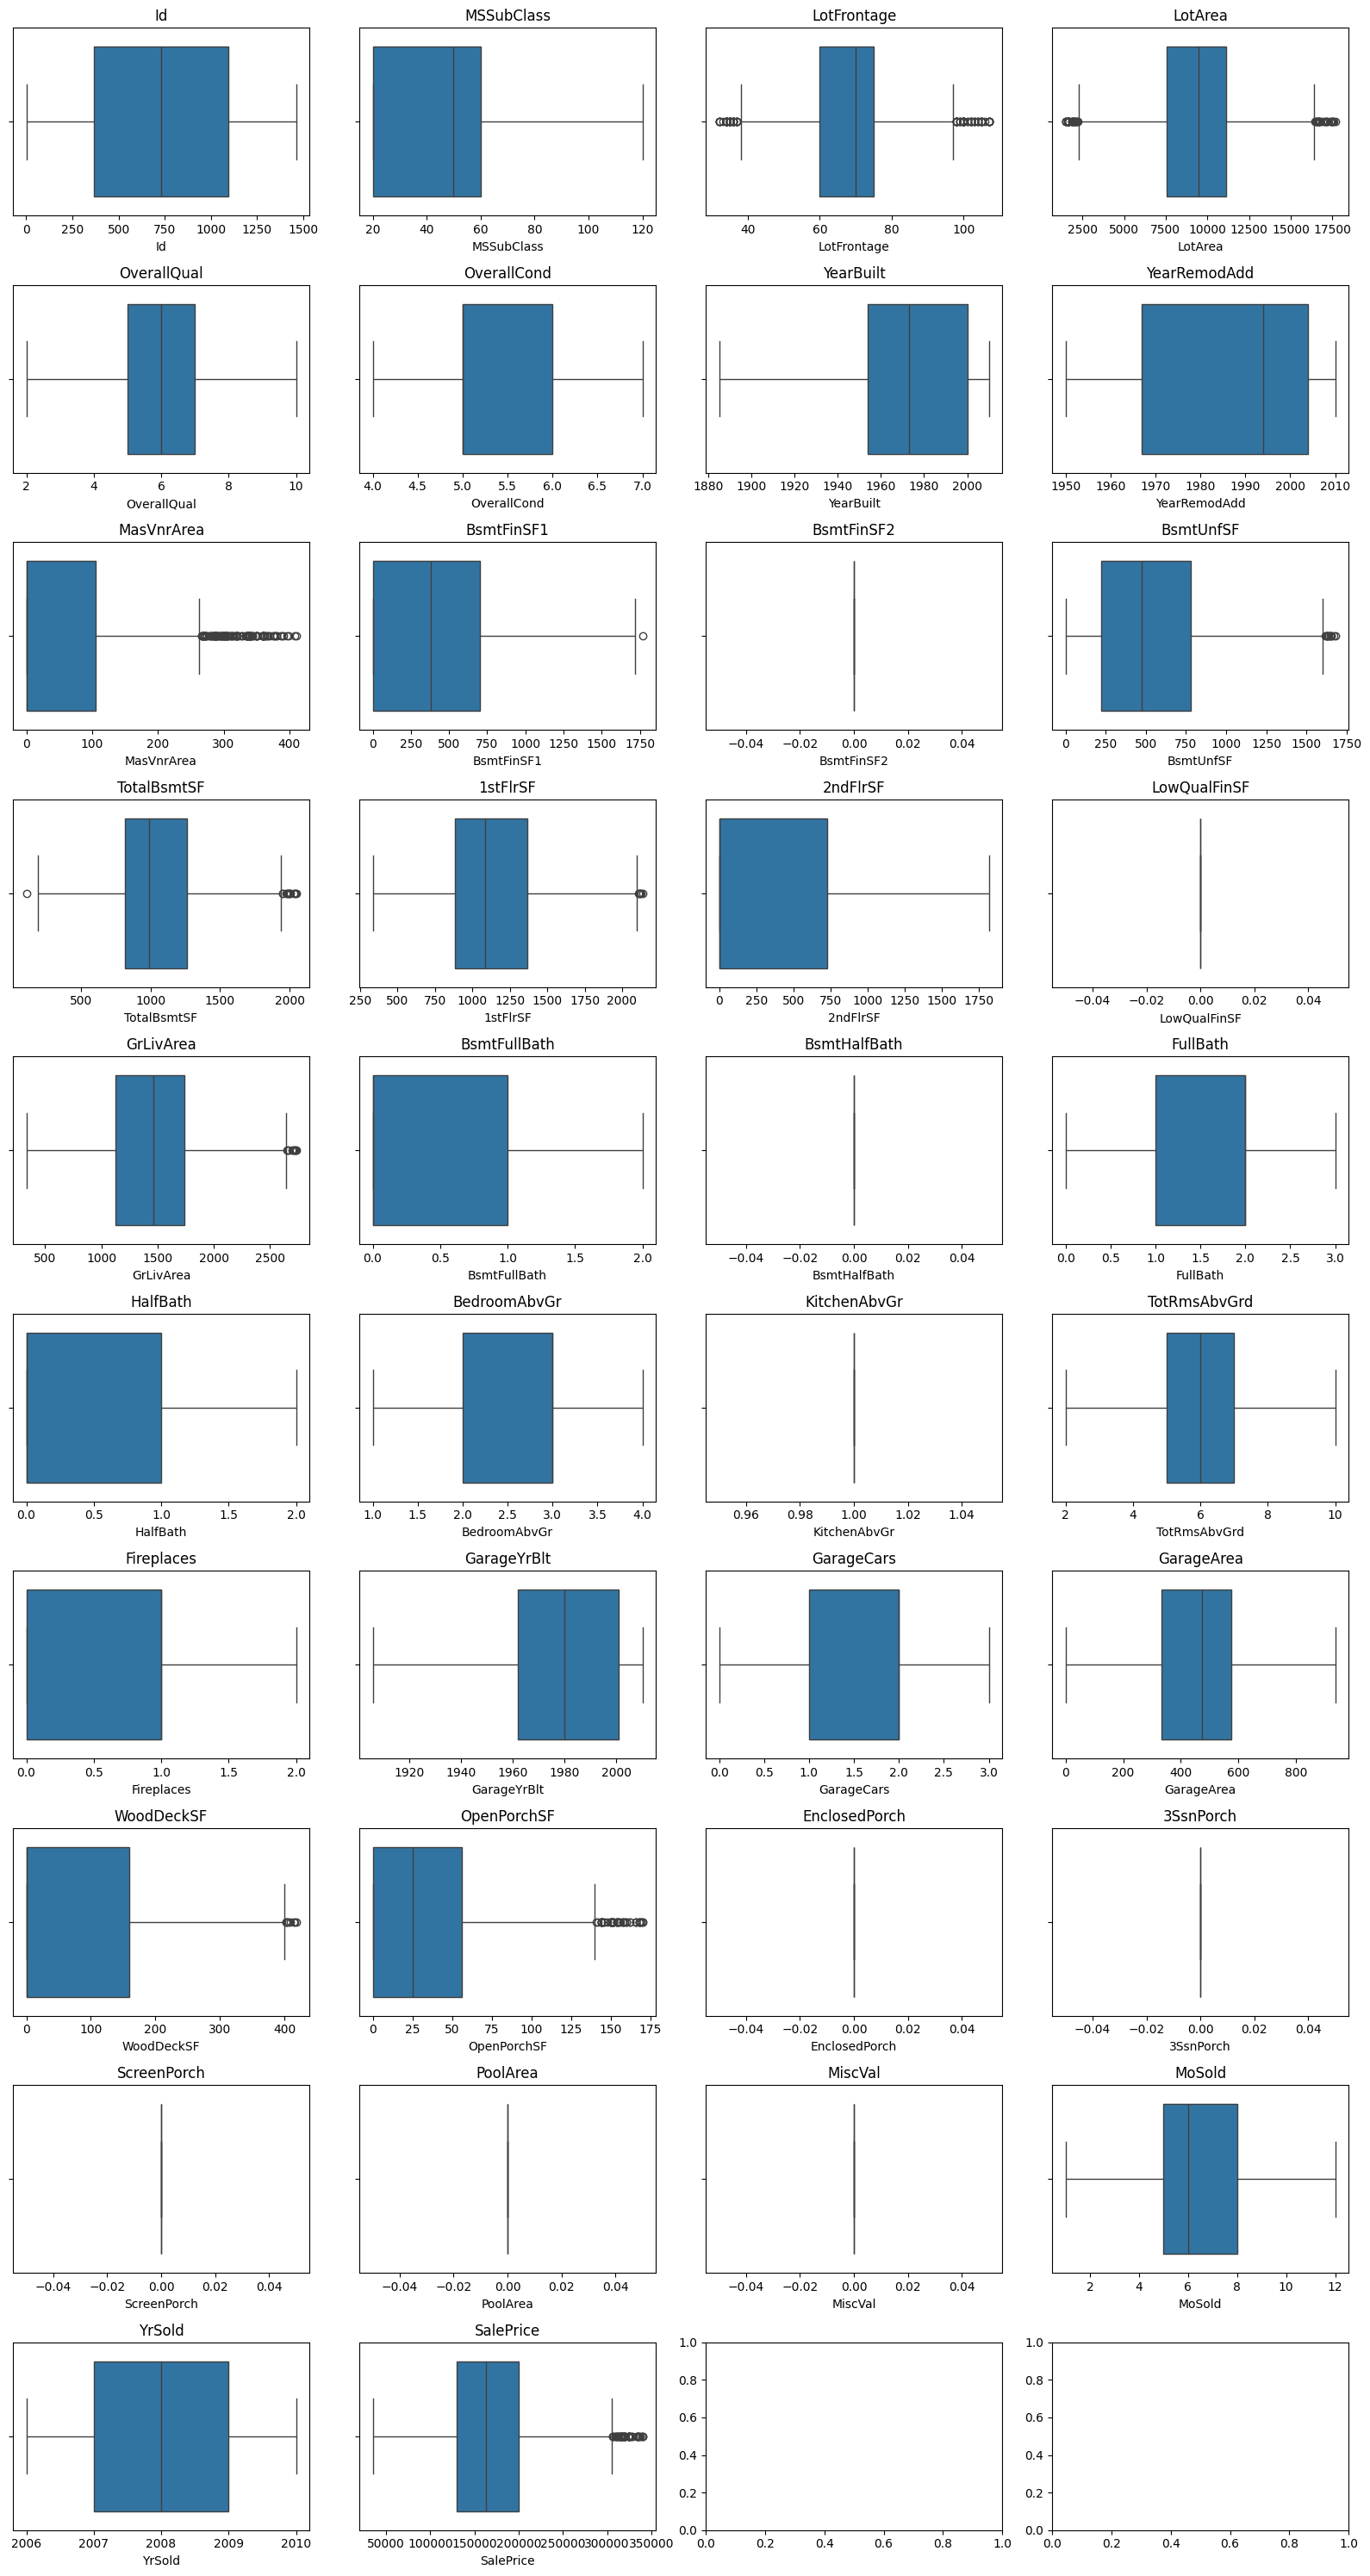

In [17]:
df_handled_outlier_numeric = df_handled_outlier.select_dtypes(include = ["int64","float64"]).columns
col = 4
row = (len(df_handled_outlier_numeric)//col)+1

fig,axes = plt.subplots(nrows = row, ncols = 4,figsize=(16,3*row))
axes = axes.flatten()

for i,x in enumerate(df_handled_outlier_numeric):
    sns.boxplot(ax = axes[i], x = df_handled_outlier[x])
    axes[i].set_title(f"{x}")
    
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

df_handled.drop(columns="Id",inplace=True)
X = df_handled.drop(columns="SalePrice")
y = df_handled["SalePrice"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.set_output(transform='pandas')
X_train_encoded_kategoric = encoder.fit_transform(X_train.select_dtypes("object"))
X_test_encoded_kategoric = encoder.transform(X_test.select_dtypes("object"))

scaler = StandardScaler()
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_encoded_numeric = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]), 
    columns=numeric_cols, 
    index=X_train.index
)
X_test_encoded_numeric = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]), 
    columns=numeric_cols, 
    index=X_test.index
)

X_train_final = pd.concat([X_train_encoded_numeric, X_train_encoded_kategoric], axis=1)
X_test_final = pd.concat([X_test_encoded_numeric, X_test_encoded_kategoric], axis=1)
print(X_train_final.shape)
print(X_test_final.shape)

(1168, 269)
(292, 269)


In [20]:
threshold = 0.8
corr_matrix_features = df_handled_outlier.drop(columns="SalePrice").corr(numeric_only=True)

high_corr_pairs = []
cols = corr_matrix_features.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_val = corr_matrix_features.iloc[i, j]
        if abs(corr_val) > threshold:
            high_corr_pairs.append((cols[i], cols[j], corr_val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Atribut 1", "Atribut 2", "Korelasi"])
high_corr_df

,Atribut 1,Atribut 2,Korelasi
0,TotalBsmtSF,1stFlrSF,0.825324
1,GarageCars,GarageArea,0.876159


In [21]:
# Buang salah satu atribut dari tiap pasangan yang sangat berkorelasi.
# Atribut yang disimpan adalah yang korelasinya lebih tinggi terhadap SalePrice.
cols_to_drop = set()
for a1, a2, corr_val in high_corr_pairs:
    corr_a1_target = abs(df_handled_outlier[a1].corr(df_handled_outlier["SalePrice"]))
    corr_a2_target = abs(df_handled_outlier[a2].corr(df_handled_outlier["SalePrice"]))
    if corr_a1_target >= corr_a2_target:
        cols_to_drop.add(a2)
    else:
        cols_to_drop.add(a1)

print("Atribut yang dibuang karena korelasi tinggi (>{:.1f}):".format(threshold), cols_to_drop)

X_train_reduced = X_train_final.drop(columns=[c for c in cols_to_drop if c in X_train_final.columns])
X_test_reduced = X_test_final.drop(columns=[c for c in cols_to_drop if c in X_test_final.columns])

print("Dimensi X_train sebelum reduksi korelasi:", X_train_final.shape)
print("Dimensi X_train setelah reduksi korelasi:", X_train_reduced.shape)

Atribut yang dibuang karena korelasi tinggi (>0.8): {'GarageArea', '1stFlrSF'}
Dimensi X_train sebelum reduksi korelasi: (1168, 269)
Dimensi X_train setelah reduksi korelasi: (1168, 267)


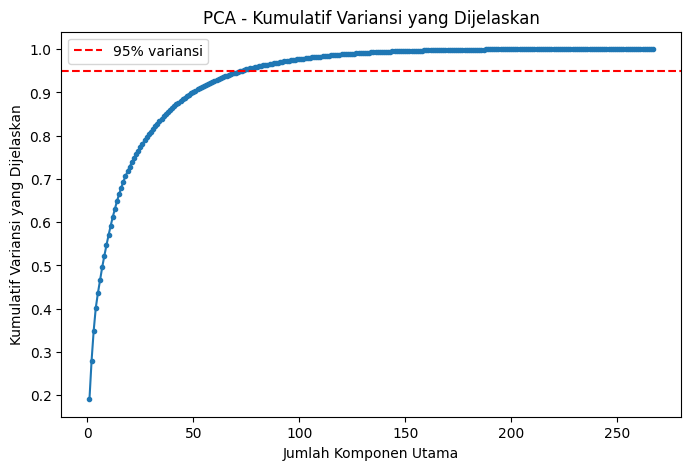

Jumlah komponen yang dipilih (menjelaskan >= 95% variansi): 73


In [22]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_train_reduced)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=3)
plt.axhline(y=0.95, color="r", linestyle="--", label="95% variansi")
plt.xlabel("Jumlah Komponen Utama")
plt.ylabel("Kumulatif Variansi yang Dijelaskan")
plt.title("PCA - Kumulatif Variansi yang Dijelaskan")
plt.legend()
plt.show()

n_components = int(np.argmax(cumulative_variance >= 0.95) + 1)
print(f"Jumlah komponen yang dipilih (menjelaskan >= 95% variansi): {n_components}")

In [23]:

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_reduced)
X_test_pca = pca.transform(X_test_reduced)

print("Dimensi sebelum PCA:", X_train_reduced.shape)
print("Dimensi setelah PCA:", X_train_pca.shape)
print("Total variansi yang dijelaskan:", round(pca.explained_variance_ratio_.sum(), 4))

Dimensi sebelum PCA: (1168, 267)
Dimensi setelah PCA: (1168, 73)
Total variansi yang dijelaskan: 0.9502
